## Setup and imports

In [1]:
EXP_NAME = "SPS_audit_100_with_ind"

In [2]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  from google.colab import userdata
  from google.colab import drive
  drive.mount('/content/drive')
  PROJECT_ROOT = userdata.get('PROJECT_ROOT')
else:
  PROJECT_ROOT = '../..'

In [3]:
print(PROJECT_ROOT)

../..


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.2)

sps_audit = pd.read_csv(f'{PROJECT_ROOT}/results/{EXP_NAME}/sps_audit.csv')
sbs_audit_baseline = pd.read_csv(f'{PROJECT_ROOT}/results/{EXP_NAME}/sps_audit_baseline.csv')
dataset = pd.read_csv(f'{PROJECT_ROOT}/data/heart_disease_cleaned.csv')

# Analysis

### Basics

In [5]:
scorings = sps_audit.groupby('feature')[['sensitivity_scoring', 'fidelity_scoring']].first()

sps_audit = sps_audit.drop(['sensitivity_scoring', 'fidelity_scoring'], axis=1)

In [6]:
iteration_per_feature = sps_audit[sps_audit['bucket'] == 'x_desc'].groupby('feature')[['roc_auc']].count()
iteration_per_feature

,roc_auc
feature,
age,45
ang,48
bp,45
chol,44
cp,48
ecg,51
mhr,53
slope,45
st,53


### Counterfactual sensitivity

In [7]:
sps_audit.groupby('feature')['cf_sensitivity'].agg(['mean','std','median']).sort_values(by='mean')

,mean,std,median
feature,,,
age,0.081536,0.025762,0.080150
ecg,0.091824,0.044832,0.084821
slope,0.096032,0.098023,0.058036
bp,0.152206,0.045139,0.152830
st,0.161525,0.043186,0.158983
mhr,0.201670,0.046748,0.204187
chol,0.261895,0.057873,0.261550
ang,0.275577,0.103580,0.279018
cp,0.376395,0.136221,0.370536


[]

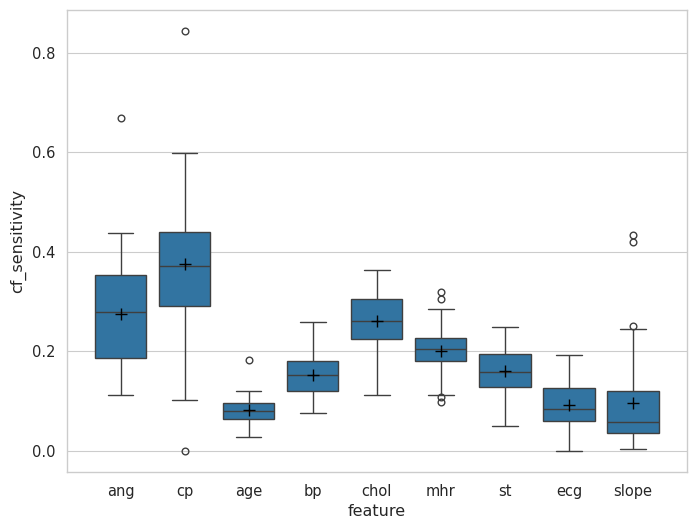

In [8]:
# Counterfactual sensitivity
f, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=sps_audit, x="feature", y="cf_sensitivity", showmeans=True, 
            meanprops={"marker": "+",
                       "markeredgecolor": "black",
                       "markersize": "8"}, ax=ax)

plt.plot()


# Utility vs Fairness trade-off

In [9]:
# sps_audit.head()

In [10]:
baseline_roc_auc = sbs_audit_baseline['roc_auc'].values[0]
baseline_ieco_mace = sbs_audit_baseline['ieco_mace'].values[0]

print(f"Baseline ROC AUC: {baseline_roc_auc}")
print(f"Baseline IECO MACE: {baseline_ieco_mace}")

Baseline ROC AUC: 0.9353782250978512
Baseline IECO MACE: 0.1029037


## Pareto Frontier 


In [11]:
feature_desc_stats = sps_audit[sps_audit['bucket'] == 'x_desc'].groupby(['feature'])[['ieco_mace', 'auprc', 'roc_auc']].median()
feature_corr_stats = sps_audit[sps_audit['bucket'] == 'x_corr'].groupby(['feature'])[['ieco_mace', 'auprc', 'roc_auc']].median()

--- Configurations on the AUPRC Pareto Frontier ---
Iteration 79, Xdesc: ['ang', 'age', 'bp', 'chol', 'mhr', 'ecg']
Iteration 41, Xdesc: ['ang', 'age', 'bp']
Iteration 28, Xdesc: ['mhr', 'ecg']
Iteration 68, Xdesc: ['bp']
|    |   roc_auc |    auprc |   ieco_mace |
|---:|----------:|---------:|------------:|
| 79 |  0.929068 | 0.928432 |  0.00788522 |
| 41 |  0.937535 | 0.931614 |  0.0459471  |
| 28 |  0.939692 | 0.934577 |  0.0580556  |
| 68 |  0.943925 | 0.937349 |  0.0626516  |


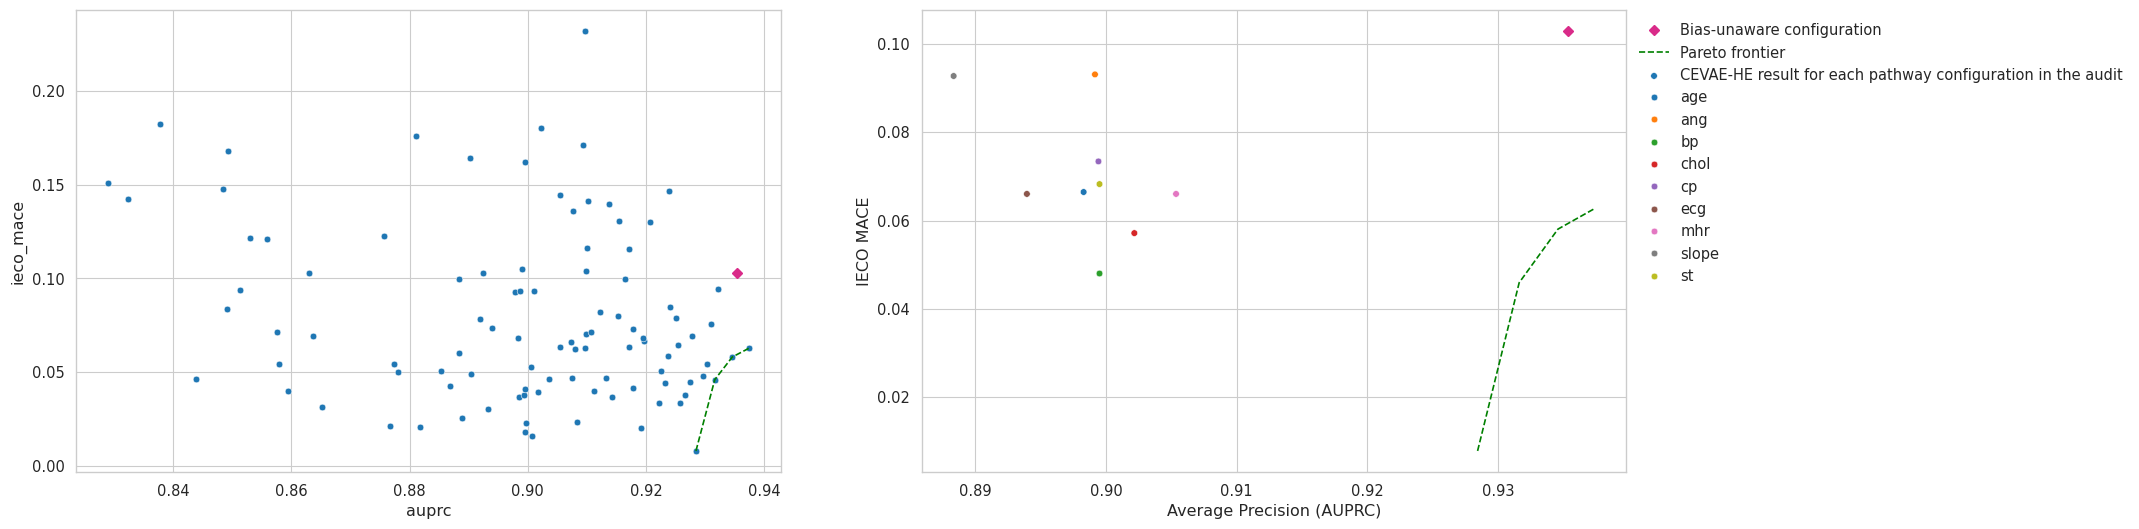

In [12]:
utility_vs_fairness = sps_audit.groupby('iteration')[['roc_auc', 'auprc','ieco_mace']].first().sort_values('ieco_mace')
x_desc_configs = sps_audit[sps_audit['bucket'] == 'x_desc'].groupby('iteration')['feature'].apply(list).to_dict()

positives = dataset[dataset['cvd'] == 1]
auprc_baseline = len(positives) / len(dataset)

pareto_frontier = []
current_max_utility = -1

print('--- Configurations on the AUPRC Pareto Frontier ---')
for idx, solution in utility_vs_fairness.iterrows():
  if solution['auprc'] > current_max_utility:
    pareto_frontier.append(solution)
    current_max_utility = solution['auprc']
    print(f'Iteration {idx}, Xdesc: {x_desc_configs[idx]}')
pareto_frontier_df = pd.DataFrame(pareto_frontier)
print(pareto_frontier_df.to_markdown())


fig, axes = plt.subplots(1, 2,  figsize=(20, 6))
axes[0].plot(baseline_roc_auc, baseline_ieco_mace, marker="D", color="#D92B89", linestyle="")
axes[1].plot(baseline_roc_auc, baseline_ieco_mace, marker="D", color="#D92B89", linestyle="")
sns.lineplot(data=pareto_frontier_df, x='auprc', y='ieco_mace', color="green", marker='', linestyle="--", errorbar=None, ax=axes[0])
sns.lineplot(data=pareto_frontier_df, x='auprc', y='ieco_mace', color="green", linestyle="--", errorbar=None, ax=axes[1])
sns.scatterplot(data=utility_vs_fairness, x='auprc', y='ieco_mace', ax=axes[0])
sns.scatterplot(data=feature_desc_stats, x='auprc', y='ieco_mace', hue='feature', color='', ax=axes[1])
# plt.axvline(auprc_baseline)
plt.xlabel('Average Precision (AUPRC)')
plt.ylabel('IECO MACE')
plt.legend(labels=[ 
                   'Bias-unaware configuration',
                   'Pareto frontier', 
                   'CEVAE-HE result for each pathway configuration in the audit'
                   ]+feature_desc_stats.index.to_list(),
           loc='upper left', bbox_to_anchor=(1, 1), edgecolor="white")

plt.show()

In [13]:
feature_desc_stats['ieco_baseline_delta'] = feature_desc_stats['ieco_mace'] - baseline_ieco_mace
feature_desc_stats['auprc_baseline_delta'] = feature_desc_stats['auprc'] - baseline_roc_auc
feature_desc_stats['roc_auc_baseline_delta'] = feature_desc_stats['roc_auc'] - baseline_roc_auc 
feature_desc_stats['ieco_corr_delta'] = feature_desc_stats['ieco_mace'] - feature_corr_stats['ieco_mace']
feature_desc_stats['auprc_corr_delta'] = feature_desc_stats['auprc'] - feature_corr_stats['auprc']
feature_desc_stats['roc_auc_corr_delta'] = feature_desc_stats['roc_auc'] - feature_corr_stats['roc_auc']

feature_desc_stats = feature_desc_stats.sort_values('ieco_baseline_delta')
print(feature_desc_stats.to_markdown())

| feature   |   ieco_mace |    auprc |   roc_auc |   ieco_baseline_delta |   auprc_baseline_delta |   roc_auc_baseline_delta |   ieco_corr_delta |   auprc_corr_delta |   roc_auc_corr_delta |
|:----------|------------:|---------:|----------:|----------------------:|-----------------------:|-------------------------:|------------------:|-------------------:|---------------------:|
| bp        |   0.0480213 | 0.899506 |  0.912213 |           -0.0548824  |             -0.0358721 |               -0.0231648 |       -0.0236416  |        -0.00988537 |         -0.00798786  |
| chol      |   0.0571612 | 0.90217  |  0.909438 |           -0.0457425  |             -0.0332087 |               -0.0259406 |       -0.0121601  |        -0.00520052 |         -0.0107636   |
| mhr       |   0.0660257 | 0.905362 |  0.916687 |           -0.036878   |             -0.0300159 |               -0.0186916 |       -0.00222395 |        -0.00013975 |         -0.000878664 |
| ecg       |   0.0660257 | 0.893951 |  0.908

[]

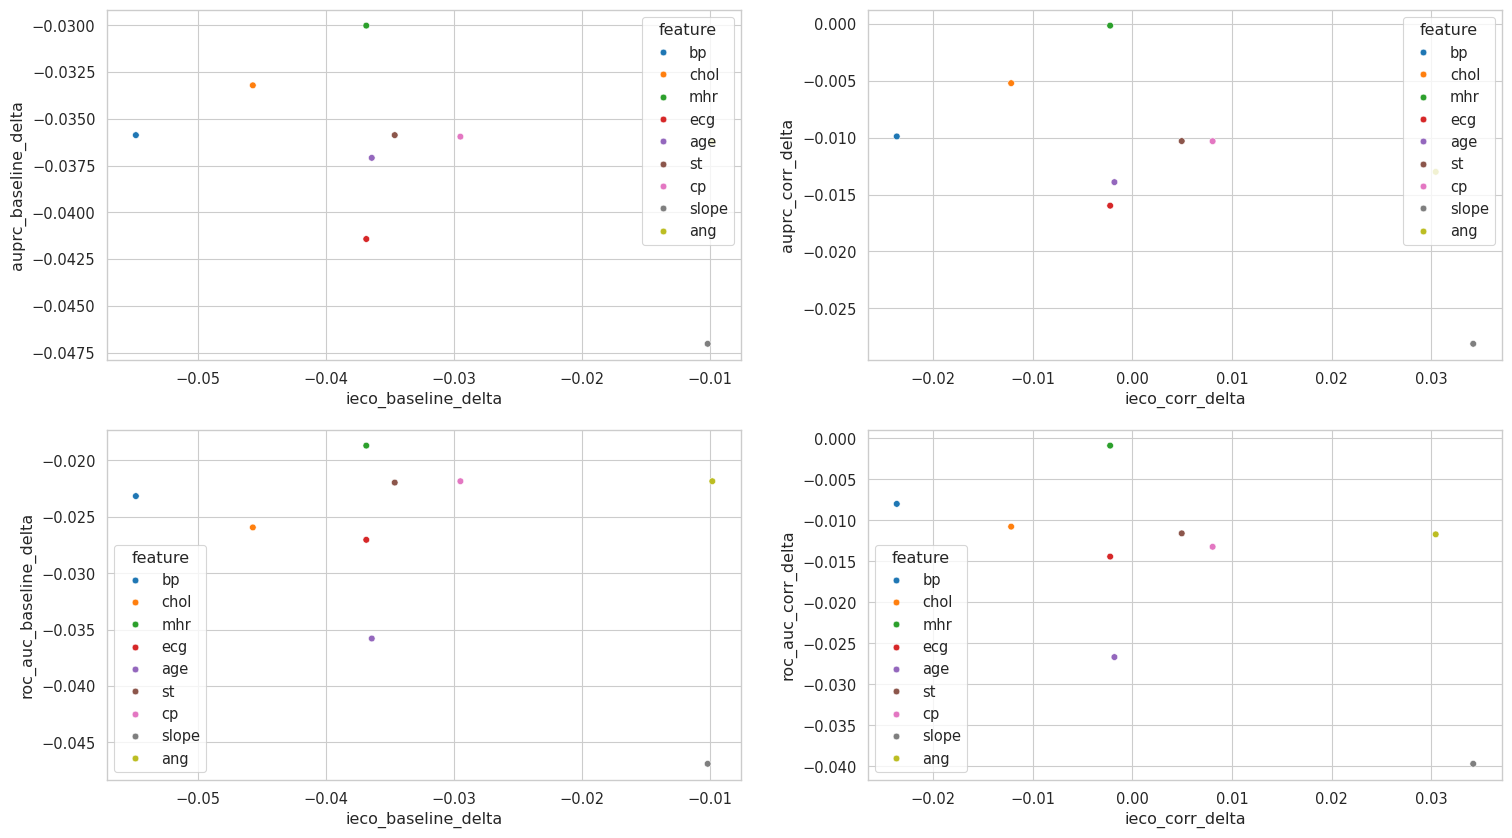

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
sns.scatterplot(data=feature_desc_stats, x='ieco_baseline_delta', y='auprc_baseline_delta', hue='feature', ax=axes[0,0])
sns.scatterplot(data=feature_desc_stats, x='ieco_baseline_delta', y='roc_auc_baseline_delta', hue='feature', ax=axes[1,0])
sns.scatterplot(data=feature_desc_stats, x='ieco_corr_delta', y='auprc_corr_delta', hue='feature', ax=axes[0,1])
sns.scatterplot(data=feature_desc_stats, x='ieco_corr_delta', y='roc_auc_corr_delta', hue='feature', ax=axes[1,1])
plt.plot()